In [ ]:
#Python Pandas + inspection of dataframes

In [21]:
import pandas as pd

customers = pd.read_csv(r'C:\Users\chira\OneDrive\Desktop\RegEx\Project October\Data Analytics Project\End to End Customer Sales Analytics\customers.csv')
orders = pd.read_csv(r'C:\Users\chira\OneDrive\Desktop\RegEx\Project October\Data Analytics Project\End to End Customer Sales Analytics\orders.csv')
products = pd.read_csv(r'C:\Users\chira\OneDrive\Desktop\RegEx\Project October\Data Analytics Project\End to End Customer Sales Analytics\products.csv')


In [3]:
customers.head()
customers.info()
customers.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   customer_id    1000 non-null   int64
 1   customer_name  1000 non-null   str  
 2   city           1000 non-null   str  
 3   state          1000 non-null   str  
 4   age            1000 non-null   int64
dtypes: int64(2), str(3)
memory usage: 39.2 KB


,customer_id,age
count,1000.000000,1000.000000
mean,1500.500000,39.148000
std,288.819436,12.278634
min,1001.000000,18.000000
25%,1250.750000,28.000000
50%,1500.500000,40.000000
75%,1750.250000,50.000000
max,2000.000000,60.000000


In [4]:
customers.isnull().sum()

customer_id      0
customer_name    0
city             0
state            0
age              0
dtype: int64

In [9]:
customers.drop_duplicates(inplace=True)

In [5]:
products.head()
products.info() 
products.describe()

<class 'pandas.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   product_id    96 non-null     int64
 1   product_name  96 non-null     str  
 2   category      96 non-null     str  
 3   price         96 non-null     int64
dtypes: int64(2), str(2)
memory usage: 3.1 KB


,product_id,price
count,96.000000,96.000000
mean,48.500000,7958.322917
std,27.856777,13368.189341
min,1.000000,345.000000
25%,24.750000,1515.000000
50%,48.500000,2887.500000
75%,72.250000,6224.500000
max,96.000000,63568.000000


In [6]:
products.isnull().sum()

product_id      0
product_name    0
category        0
price           0
dtype: int64

In [10]:
products.drop_duplicates(inplace=True)

In [22]:
orders.head()
orders.info()
orders.describe()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          2000 non-null   int64  
 1   customer_id       2000 non-null   int64  
 2   product_id        2000 non-null   int64  
 3   order_date        2000 non-null   str    
 4   quantity          2000 non-null   int64  
 5   unit_price        2000 non-null   int64  
 6   discount_percent  2000 non-null   int64  
 7   order_status      2000 non-null   str    
 8   total_amount      2000 non-null   float64
dtypes: float64(1), int64(6), str(2)
memory usage: 140.8 KB


,order_id,customer_id,product_id,quantity,unit_price,discount_percent,total_amount
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,51000.500000,1501.102500,48.897500,3.05500,7734.811500,8.152500,21205.115675
std,577.494589,288.838503,27.520405,1.45569,12673.272453,6.480374,40418.961082
min,50001.000000,1001.000000,1.000000,1.00000,345.000000,0.000000,287.200000
25%,50500.750000,1257.000000,24.000000,2.00000,1539.000000,5.000000,3291.062500
50%,51000.500000,1504.500000,50.000000,3.00000,3163.000000,5.000000,7583.850000
75%,51500.250000,1752.500000,73.000000,4.00000,6352.000000,15.000000,18809.625000
max,52000.000000,2000.000000,96.000000,5.00000,63568.000000,20.000000,305575.000000


In [23]:
orders.isnull().sum()

order_id            0
customer_id         0
product_id          0
order_date          0
quantity            0
unit_price          0
discount_percent    0
order_status        0
total_amount        0
dtype: int64

In [24]:
orders.drop_duplicates(inplace=True)

In [25]:
orders['order_date'] = pd.to_datetime(orders['order_date'])

In [26]:
orders['total_amount'] = orders['quantity'] * orders['unit_price']
# These steps are to know that we know pandas rather than SQL. We can do all the operations in pandas that we can do in SQL.

In [ ]:
# now i am connecting to mysql database and creating a database and tables and inserting the data from the csv files into the tables.

In [27]:
import mysql.connector as sql
import pandas as pd

conn = sql.connect(host='localhost', user='root', password='1234', database='ecommerce_project')


In [30]:
query = """with product_cat as(
Select p.product_id, p.product_name, p.category, sum(o.quantity) as total_quantity
from products as p
join orders as o
on p.product_id = o.product_id
group by p.product_id, p.product_name, p.category
),
ranking as(
Select *, rank() over(partition by category order by total_quantity desc) as rnk from product_cat
)
Select * from ranking where rnk=1;
"""


In [31]:
df = pd.read_sql(query, conn)
df

C:\Users\chira\AppData\Local\Temp\ipykernel_17424\1061802609.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,product_id,product_name,category,total_quantity,rnk
0,83,Moisturizer 3,Beauty,72.0,1
1,59,Python Book 11,Books,60.0,1
2,48,Sneakers 16,Clothing,67.0,1
3,13,Mouse 13,Electronics,58.0,1
4,30,Air Fryer 14,Home & Kitchen,58.0,1
5,71,Cricket Bat 7,Sports,61.0,1


In [32]:
df.loc[df['total_quantity'].idxmax()]

product_id                   83
product_name      Moisturizer 3
category                 Beauty
total_quantity             72.0
rnk                           1
Name: 0, dtype: object

In [33]:
df.sort_values(by='total_quantity', ascending=False)

,product_id,product_name,category,total_quantity,rnk
0,83,Moisturizer 3,Beauty,72.0,1
2,48,Sneakers 16,Clothing,67.0,1
5,71,Cricket Bat 7,Sports,61.0,1
1,59,Python Book 11,Books,60.0,1
3,13,Mouse 13,Electronics,58.0,1
4,30,Air Fryer 14,Home & Kitchen,58.0,1


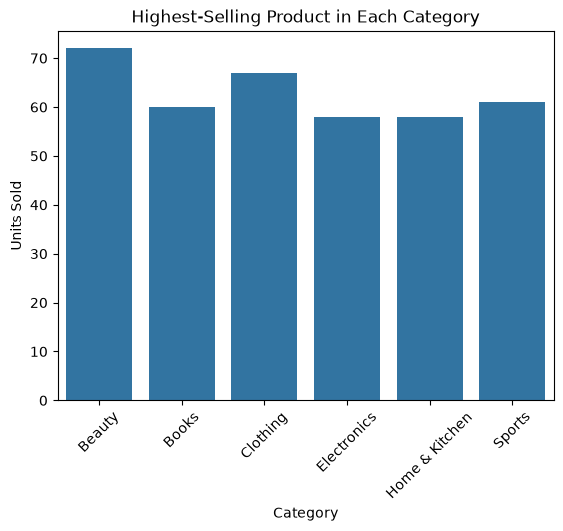

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(
    data=df,
    x="category",
    y="total_quantity"
)

plt.title("Highest-Selling Product in Each Category")
plt.xlabel("Category")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.show()

In [43]:
query2 = '''Select c.customer_id, c.customer_name, round(sum(o.total_amount)) as most_spent_cust
from customers as c
join orders as o
on c.customer_id = o.customer_id
group by c.customer_id, c.customer_name
order by most_spent_cust desc;
'''

In [44]:
df = pd.read_sql(query2, conn)
df

C:\Users\chira\AppData\Local\Temp\ipykernel_17424\961303971.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query2, conn)


,customer_id,customer_name,most_spent_cust
0,1649,Vikas Joshi,371215.0
1,1263,Aditya Kumar,348503.0
2,1026,Amit Mehta,338172.0
3,1040,Meera Gupta,322038.0
4,1427,Rohan Singh,314348.0
...,...,...,...
728,1804,Arjun Verma,546.0
729,1821,Aarav Sharma,541.0
730,1212,Ananya Yadav,522.0
731,1198,Riya Agarwal,515.0


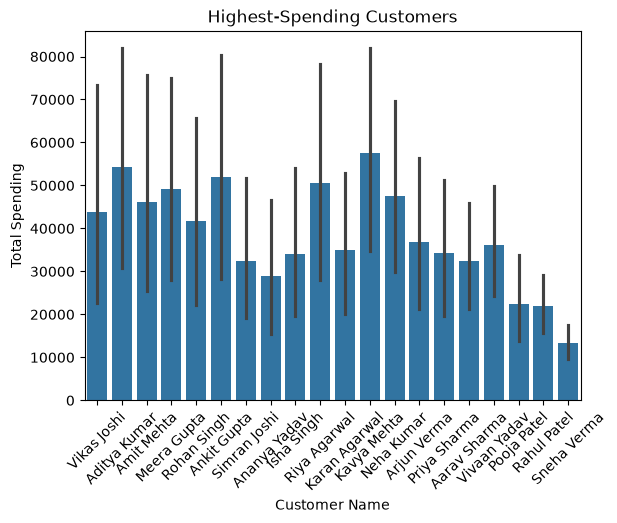

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(
    data=df,
    x="customer_name",
    y="most_spent_cust"
)

plt.title("Highest-Spending Customers")
plt.xlabel("Customer Name")
plt.ylabel("Total Spending")
plt.xticks(rotation=45)
plt.show()

In [46]:
query = '''Select 
	p.product_name, sum(o.total_amount) as per_product_revenue
from 
	products as p
join 
	orders as o
on 
	p.product_id = o.product_id
group by p.product_name
order by per_product_revenue desc;'''

In [47]:
df = pd.read_sql(query, conn)
df

C:\Users\chira\AppData\Local\Temp\ipykernel_17424\1061802609.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,product_name,per_product_revenue
0,Mouse 13,3275764.00
1,Smartwatch 15,2374515.00
2,Smartphone 2,1895348.00
3,Keyboard 4,1595556.80
4,Headphones 11,1472131.00
...,...,...
91,Python Book 1,18383.45
92,Sneakers 10,16983.15
93,Python Book 16,13749.70
94,Data Science Book 8,13593.00


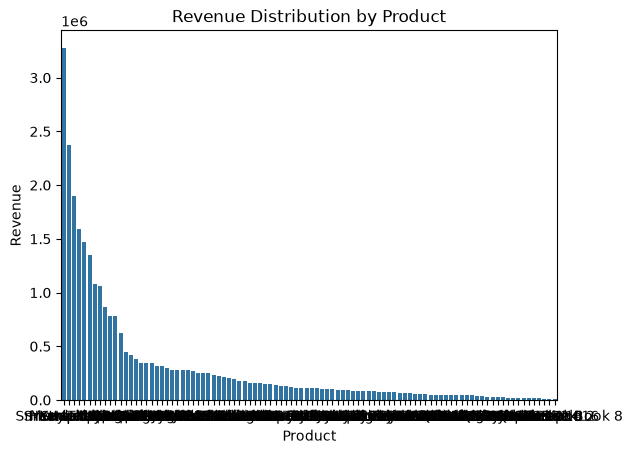

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.barplot(data=df, x="product_name", y="per_product_revenue")
plt.title("Revenue Distribution by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.show()

In [57]:
query='''Select product_id, sum(total_amount) as 'total revenue'
from orders
group by product_id;'''

In [58]:
df = pd.read_sql(query, conn)
df

C:\Users\chira\AppData\Local\Temp\ipykernel_17424\1061802609.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,product_id,total revenue
0,1,786369.35
1,2,1895348.00
2,3,1061633.55
3,4,1595556.80
4,5,870146.75
...,...,...
91,92,22411.00
92,93,49974.75
93,94,43859.25
94,95,99311.10


C:\Users\chira\AppData\Local\Temp\ipykernel_17424\2812408421.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Revenue")


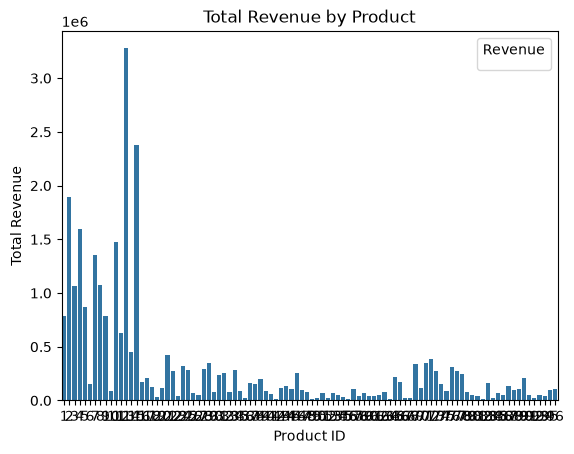

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.barplot(data = df, x = "product_id", y = "total revenue")
plt.title("Total Revenue by Product")   
plt.xlabel("Product ID")
plt.ylabel("Total Revenue")
plt.legend(title="Revenue")
plt.show()